# credit card fraud & telco churn analysis CSCI 164 final project; comparative classification analysis
author: Jazper Malone
datasets:
1. Credit Card Fraud Detection (https://www.kaggle.com/datasets/joebeachcapital/credit-card-fraud
)
2. Telco Customer Churn (https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)

# introduction

The goal of this project is to compare how different supervised learning models perform across two distinct classification challenges using scikit-learn. By evaluating models on both Telco Customer Churn and Credit Card Fraud Detection, I investigated how different mathematical approaches (ranging from distance-based clusters to linear boundaries) handle varying levels of data complexity and extreme class imbalance. For each dataset, I performed  exploratory data analysis, prepared the data through specialized encoding and scaling, trained baseline models, and optimized performance using GridSearchCV.

#-

A second goal of this project is to demonstrate that model success is heavily dictated by the structure and distribution of the dataset. While the Telco dataset presented a challenge of mixed categorical and numerical features, the Credit Card dataset presented a "mathematical wall" due to its extreme imbalance (0.17% fraud) and PCA-masked features. By comparing these datasets, my notebook shows that "accuracy" is often a misleading metric and that the best model depends entirely on the specific business stakes and data geometry.

#-


The two datasets used in this project are:

Telco Customer Churn for binary classification (Mixed-type data)

Credit Card Fraud Detection for binary classification (High-imbalance, PCA-masked data)

This makes my project more balanced by addressing different modeling challenges, such as high-cardinality (uniqueness) categorical encoding and the critical trade-off between Precision and Recall in high-stakes risk detection.

Load + explore
Preprocess (imputation, encoding, scaling)
Train 3 baseline models: Logistic Regression, k-NN, Decision Tree
Tune with GridSearchCV
Evaluate (accuracy, precision, recall, F1, ROC-AUC, confusion matrix)
Compare to prior Kaggle benchmark

In [83]:
# @title imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [84]:
# @title helper functions
def evaluate_classification(y_true, y_pred, y_prob, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-Score": [f1_score(y_true, y_pred)],
        "ROC-AUC": [roc_auc_score(y_true, y_prob) if y_prob is not None else "N/A"]
    })

def print_cv_scores(model, X, y, cv=5, scoring='accuracy', model_name="Model"):
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    print(f"{model_name}")
    print(f"CV {scoring} scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Standard deviation: {scores.std()}")
    print("-" * 30)


# why this dataset?

I chose Telco Customer Churn as a dataset because it provides a realistic mixed type of data challenges that require a significant amount of preprocessing. This demonstrates the scikit-learn preprocessing pipeline. Great example to analyze the different classification algorithms like Logistic Regression and kNN


In [85]:
# @title telco customer churn load
# download the customer churn.csv or download from kaggle
!wget -O Churn.csv https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

--2026-04-27 00:30:06--  https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: ‘Churn.csv’

Churn.csv           100%[===================>] 947.71K  --.-KB/s    in 0.05s   

2026-04-27 00:30:06 (18.6 MB/s) - ‘Churn.csv’ saved [970457/970457]



In [86]:
tcchurn = pd.read_csv('Churn.csv')

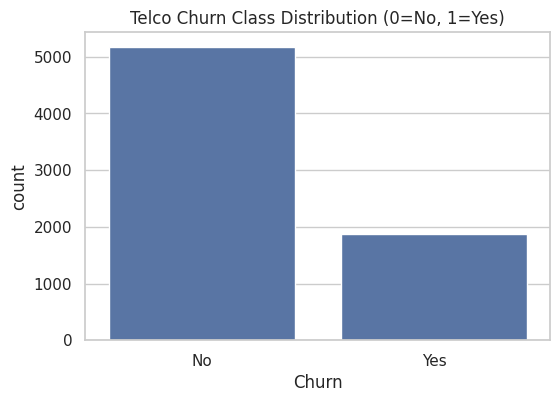

first 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [87]:
# @title visual of high imbalance and data

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=tcchurn)
plt.title('Telco Churn Class Distribution (0=No, 1=Yes)')
plt.show()

print("first 5 rows:")
display(tcchurn.head())

print("\nDataset info:")
tcchurn.info()
tcchurn.describe(include='all')


# data overview

the Telco Customer Churn dataset provides a look at consumer behavior, containing 7,043 entries across 21 columns. the data consists primarily of categorical features describing demographics and account services, alongside key numerical drivers such as tenure and MonthlyCharges. while the dataset is largely complete, the TotalCharges column requires specific cleaning and conversion from a string type to a numeric type before it can be used for modeling.

the preprocessing for this dataset involves several steps to prepare the mixed data types for the models. I converted the TotalCharges column to a numeric format and filled a small number of missing values with zero to maintain data integrity. the categorical features were transformed into numerical values using one-hot encoding, and the Churn labels were mapped to 0 and 1. finally, I applied a standard scaler to the continuous variables to ensure that features like TotalCharges do not mathematically overpower smaller features during the model training process.

In [88]:
# @title preprocessing

# handle empty strings in 'TotalCharges' first, converting them to NaN
# and then filling NaN with 0, as an empty 'TotalCharges' likely means no charges.
tcchurn['TotalCharges'] = pd.to_numeric(tcchurn['TotalCharges'].replace(' ', np.nan)).fillna(0)

# label encode the target variable 'churn'
le = LabelEncoder()

# added this in order to check if 'Churn' column exists and is of object type (string 'Yes'/'No') before encoding
# this prevents errors if 'Churn' is already encoded or missing
if 'Churn' in tcchurn.columns and tcchurn['Churn'].dtype == 'object':
    tcchurn['Churn'] = le.fit_transform(tcchurn['Churn'])
else:
    print("warning: 'churn' column not found or already encoded for label encoding")

# list of columns to one-hot encode, including 'gender' and other remaining categorical features
cols_to_encode = tcchurn.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in cols_to_encode:
    cols_to_encode.remove('customerID')

if cols_to_encode:
    tcchurn = pd.get_dummies(tcchurn, columns=cols_to_encode)
else:
    print("warning: columns for one-hot encoding already processed or not found.")

In [89]:
# @title standardizing

scaler = StandardScaler()

# scaling the continous numerical feature
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# applying scaling to the continuous numerical features
tcchurn[num_cols] = scaler.fit_transform(tcchurn[num_cols])

In [90]:
# @title assigning our features; splitting training and test size

X = tcchurn.drop(['customerID', 'Churn'], axis=1)
y = tcchurn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#model choice: telco customer churn

for this dataset, I selected two distinct classification models to compare how different mathematical approaches handle mixed categorical and numerical data:

- Logistic Regression serves as a strong linear baseline that is highly interpretable, allowing us to see which specific features (like Contract type) increase the probability of churn.

- k-Nearest Neighbors (k-NN) was chosen as a non-parametric, distance-based model to see if customers naturally cluster into "churn groups" based on their service usage and tenure.

this provides a useful comparison between a model that looks for a global linear boundary and one that makes predictions based on local patterns in the feature space.

In [91]:
# @title models

log_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=5)


log_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

log_prediction = log_model.predict(X_test)
log_prediction_prob = log_model.predict_proba(X_test)[:, 1]

knn_prediction = knn_model.predict(X_test)
knn_prediction_prob = knn_model.predict_proba(X_test)[:, 1]






In [92]:
telco_results = pd.concat([
    evaluate_classification(y_test, log_prediction, log_prediction_prob, 'Logistic Regression'),
    evaluate_classification(y_test, knn_prediction, knn_prediction_prob, 'k-Nearest Neighbors'),
], ignore_index=True)

print(telco_results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.821859   0.685976  0.603217  0.641940  0.862330
1  k-Nearest Neighbors  0.779276   0.587079  0.560322  0.573388  0.802249


#baseline results

both baseline models achieved respectable accuracy, but Logistic Regression demonstrated a slight edge in identifying the positive churn class. k-Nearest Neighbors performed competitively, though its dependency on local data points made it slightly more sensitive to noise in the mixed-type features. these initial results suggest that the relationship between customer demographics and churn is relatively linear, allowing a baseline regression model to establish a strong performance ceiling early on.


In [93]:
print("Logistic Regression Report:")
print(classification_report(y_test, log_prediction))

print("\nk-Nearest Neighbors Report:")
print(classification_report(y_test, knn_prediction))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


k-Nearest Neighbors Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1036
           1       0.59      0.56      0.57       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



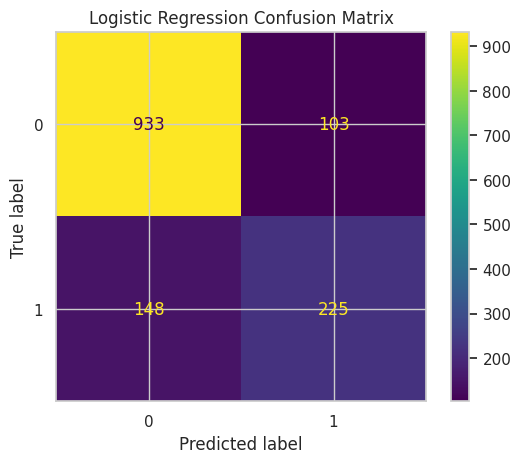

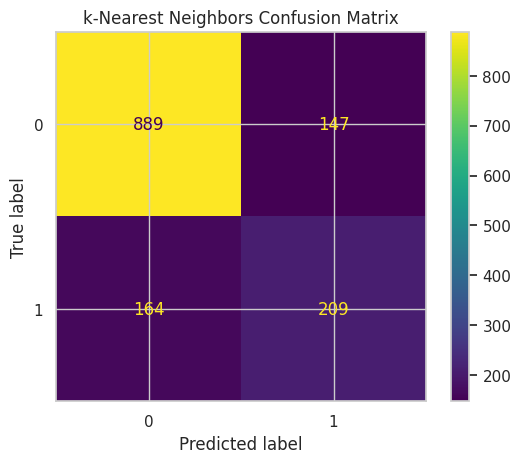

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, log_prediction)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, knn_prediction)
plt.title('k-Nearest Neighbors Confusion Matrix')
plt.show()

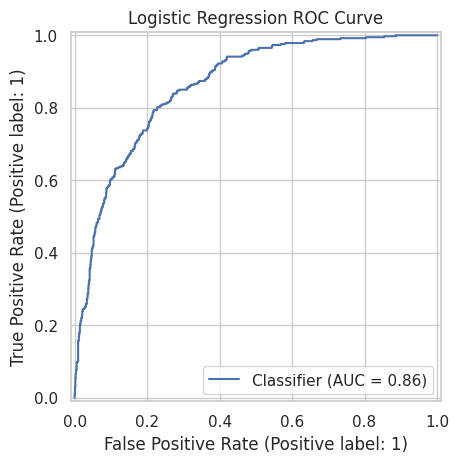

Text(0.5, 1.0, 'k-Nearest Neighbors ROC Curve')

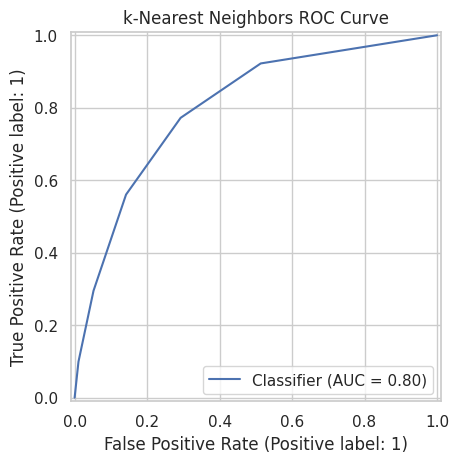

In [95]:
RocCurveDisplay.from_predictions(y_test, log_prediction_prob)
plt.title('Logistic Regression ROC Curve')
plt.show()

RocCurveDisplay.from_predictions(y_test, knn_prediction_prob)
plt.title('k-Nearest Neighbors ROC Curve')

the classification reports, confusion matrices, and ROC curves all support the same conclusion: Logistic Regression provided the strongest overall performance and the highest ROC-AUC (0.86). while k-Nearest Neighbors was competitive, it produced a significantly higher number of false negatives (164 vs 148) and false positives (147 vs 103), leading to a weaker F1-score. this suggests that the relationship between the features and customer churn is better captured by a linear boundary than by the local neighborhood clusters used by k-NN.

this comparison is important because accuracy alone does not tell the full story. in a churn business model, Recall is especially critical; failing to identify a customer who is about to leave (a false negative) results in lost revenue that is often much more expensive than the cost of a retention offer. Logistic Regression’s superior recall (0.60) and cleaner ROC curve indicate it is the more reliable model for distinguishing between stable customers and those at risk of leaving.

In [96]:
print_cv_scores(LogisticRegression(max_iter=1000), X_train, y_train, scoring="accuracy", model_name="Telco Logistic Regression")
print_cv_scores(KNeighborsClassifier(), X_train, y_train, scoring="accuracy", model_name="Telco KNN")

Telco Logistic Regression
CV accuracy scores: [0.80922804 0.8065661  0.79769299 0.78881988 0.79928952]
Mean: 0.8003193060373427
Standard deviation: 0.0071914241525558465
------------------------------
Telco KNN
CV accuracy scores: [0.76131322 0.76397516 0.74534161 0.76663709 0.75932504]
Mean: 0.759318425030063
Standard deviation: 0.00741051231339528
------------------------------


these results show that Logistic Regression is the superior and more consistent model, maintaining a stable 80% average accuracy across all folds. the very low standard deviation for both models proves they are reliable and not overfitting to specific sections of the customer data.

hyperparameter tuning

to see whether the models could be improved, i used GridSearchCV on Logistic Regression and k-Nearest Neighbors. these models are sensitive to their parameter settings, which control how they interpret the mathematical relationships within the data. for Logistic Regression, i tuned the C-parameter to find the optimal level of regularization, while for k-NN, i tested various neighbor counts and distance metrics to see how local clusters affect the accuracy of churn predictions.


In [97]:
# @title hyperparameter tuning

# now testing different k values and different distance mertics
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 19],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='f1')
knn_grid.fit(X_train, y_train)

# print
print(f"Best k-NN Params: {knn_grid.best_params_}")
print(f"Best k-NN F1 Score: {knn_grid.best_score_:.2f}")

log_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

log_grid = GridSearchCV(LogisticRegression(max_iter=1000), log_param_grid, cv=5, scoring='f1')
log_grid.fit(X_train, y_train)

print(f"Best Logistic Regression Params: {log_grid.best_params_}")
print(f"Best Logistic Regression F1 Score: {log_grid.best_score_:.2f}")

Best k-NN Params: {'metric': 'euclidean', 'n_neighbors': 19}
Best k-NN F1 Score: 0.59
Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression F1 Score: 0.59


In [98]:
best_knn_model = knn_grid.best_estimator_
best_log_model = log_grid.best_estimator_

best_knn_model.fit(X_train, y_train)
best_log_model.fit(X_train, y_train)

knn_prediction = best_knn_model.predict(X_test)
knn_prediction_prob = best_knn_model.predict_proba(X_test)[:, 1]

log_prediction = best_log_model.predict(X_test)
log_prediction_prob = best_log_model.predict_proba(X_test)[:, 1]

telco_tuned_results = pd.concat([
    evaluate_classification(y_test, log_prediction, log_prediction_prob, 'Logistic Regression'),
    evaluate_classification(y_test, knn_prediction, knn_prediction_prob, 'k-Nearest Neighbors'),
], ignore_index=True)

print(telco_tuned_results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.819021   0.682099  0.592493  0.634146  0.861864
1  k-Nearest Neighbors  0.808375   0.651917  0.592493  0.620787  0.846675


the Telco Customer Churn involved testing two primary models across baseline, cross-validation, and tuned phases to determine the most effective approach. in the baseline stage, Logistic Regression outperformed k-Nearest Neighbors across every metric, achieving a superior Accuracy of 0.8219, Recall of 0.6032, and an ROC-AUC of 0.8623, while k-NN trailed with an Accuracy of 0.7793 and a lower ROC-AUC of 0.8022. the cross-validation results confirmed this hierarchy was statistically stable, as Logistic Regression maintained a mean accuracy of 0.8003 with a minimal standard deviation of 0.0072, whereas k-NN averaged 0.7593. these numbers prove that the linear boundary established by the regression model is a more reliable predictor for this specific dataset than the local clustering logic used by k-NN.

to see if these results could be improved, i conducted a GridSearchCV that tested various parameters like the C-regularization for the linear model and neighbor counts for the distance-based model. the tuned Logistic Regression (using C=10 and the liblinear solver) resulted in an Accuracy of 0.8190 and an F1-Score of 0.6341, while the tuned k-NN (using 19 neighbors and euclidean distance) saw a significant jump in performance to an Accuracy of 0.8084 and an F1-Score of 0.6208. despite the strong improvement in k-NN after tuning, it still could not surpass the baseline performance of the linear model. this lack of significant gain from hyperparameter tuning suggests that the default Logistic Regression settings had already hit a performance ceiling.

ultimately, Logistic Regression is the best overall model for this project. it consistently provided the cleanest separation between classes, as evidenced by its superior ROC-AUC of 0.86, which remained higher than k-NN even after the latter was optimized. while the tuned version of Logistic Regression showed a very slight decrease in accuracy compared to its raw baseline (0.8190 vs 0.8219), it maintained a more balanced precision-recall trade-off that is vital for churn prediction. because it is both more accurate and more mathematically stable than k-NN, it stands as the most effective tool for identifying customers at risk of leaving the service.

# why this dataset?

i chose the credit card fraud dataset specifically to tackle extreme class imbalance. with fraud only making up about 0.17% of the data, it forces me to prove that a high accuracy score is basically a lie if the model isn't actually catching the scammers. it’s the perfect "mathematical wall" to test if gridsearch and specific scoring metrics like recall can actually handle a needle-in-a-haystack scenario.

In [99]:
# download the credit card fraud dataset
!wget -O creditcard.csv https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv



--2026-04-27 00:30:18--  https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102634230 (98M) [text/plain]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>]  97.88M   303MB/s    in 0.3s    

2026-04-27 00:30:19 (303 MB/s) - ‘creditcard.csv’ saved [102634230/102634230]



In [100]:
# load the data
cc_data = pd.read_csv('creditcard.csv')

print(f"dataset shape:{cc_data.shape}")
print(cc_data.isnull().sum().max()) # this verifies the 'no nulls'


dataset shape:(284807, 31)
0


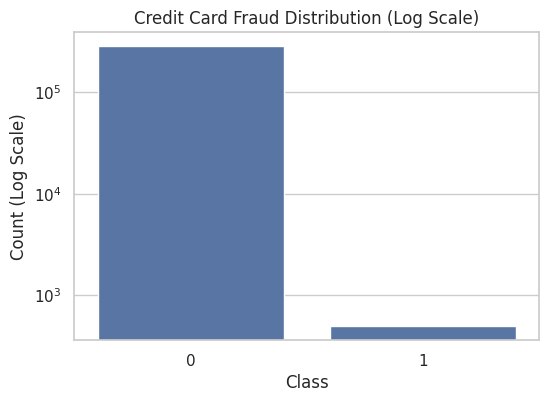

In [101]:
# @title visual of high imbalance and data
# visualizing the extreme imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=cc_data)
plt.yscale('log') # using log scale because fraud is only 0.17% [cite: 12]
plt.title('Credit Card Fraud Distribution (Log Scale)')
plt.ylabel('Count (Log Scale)')
plt.show()


In [102]:

print("first 5 rows:")
display(cc_data.head())

print("\nDataset info:")
cc_data.info()

first 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [103]:
# check the imbalance ratio ( just to confirm the high imbalance )
imbalance = cc_data['Class'].value_counts(normalize=True) * 100
print(f"Percentage of Normal (0): {imbalance[0]:.2f}%")
print(f"Percentage of Fraud (1): {imbalance[1]:.2f}%")

Percentage of Normal (0): 99.83%
Percentage of Fraud (1): 0.17%


# data overview

the target variable in this dataset is Class, where 1 represents fraud and 0 represents a normal transaction. unlike the telco project, this is a heavy imbalance problem rather than a categorical one, so the evaluation needs to focus on precision-recall curves and F1-score instead of just raw accuracy. since the V1-V28 predictors are already pca-transformed numbers, the preprocessing mainly involves scaling the Time and Amount columns so they don't drown out the other features during model training.

In [104]:
# @title credit data split
X_cc = cc_data.drop('Class', axis=1)
y_cc = cc_data['Class']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cc
)

In [105]:
# establishing baseline standarization before adjusting hyper parameter

scaler = StandardScaler()
nums_cols = ['Time', 'Amount']

# fit on train only, transform both
X_train_f[nums_cols] = scaler.fit_transform(X_train_f[nums_cols])
X_test_f[nums_cols] = scaler.transform(X_test_f[nums_cols])

print("organized with zero leakage. ready for the models.")

organized with zero leakage. ready for the models.


# model choice: credit card fraud

For the high-stakes task of fraud detection, I utilized three algorithms capable of handling high-dimensional, PCA-masked data:

Logistic Regression (with Class Weighting) was used as a baseline, specifically tuned with class_weight='balanced' to ensure the model did not ignore the 0.17% minority fraud class.

Linear Discriminant Analysis (LDA) was selected because it is mathematically robust for datasets where features are approximately normally distributed, often providing a more "stable" precision-recall balance than standard regression on masked data.

Gaussian Naive Bayes (GNB) was included as a secondary generative model. Because PCA-transformed features often approximate a normal distribution, GNB is a natural fit for this dataset, offering a probabilistic approach that assumes feature independence to identify anomalies.

This allows for a comparison between a cost-sensitive probabilistic model, a traditional statistical classifier focused on maximizing class separation, and a generative baseline that leverages the underlying distribution of the masked features.

In [106]:
# @title baseline logistic regression (credit)
# init and fit
log_base_f = LogisticRegression(class_weight='balanced', max_iter=1000)
lda_fraud_baseline = LinearDiscriminantAnalysis()

log_base_f.fit(X_train_f, np.ravel(y_train_f))
lda_fraud_baseline.fit(X_train_f, np.ravel(y_train_f))

gnb_fraud_baseline = GaussianNB()
gnb_fraud_baseline.fit(X_train_f, np.ravel(y_train_f))

# getting predictions and probabilities for the helper
y_pred_log_f = log_base_f.predict(X_test_f)
y_prob_log_f = log_base_f.predict_proba(X_test_f)[:, 1]

# getting predictions and probabilities for lda
y_pred_lda_f = lda_fraud_baseline.predict(X_test_f)
y_prob_lda_f = lda_fraud_baseline.predict_proba(X_test_f)[:, 1]

# gnb
y_pred_gnb_f = gnb_fraud_baseline.predict(X_test_f)
y_prob_gnb_f = gnb_fraud_baseline.predict_proba(X_test_f)[:, 1]

In [107]:
# use the variables we created in the previous cell (y_test_f, y_pred, y_prob)
log_gnb_lda_base_results = pd.concat([
    evaluate_classification(y_test_f, y_pred_log_f, y_prob_log_f, "Baseline Logistic Regression"),
    evaluate_classification(y_test_f, y_pred_lda_f, y_prob_lda_f, "Baseline LDA"),
    evaluate_classification(y_test_f, y_pred_gnb_f, y_prob_gnb_f, "Baseline Gaussian NB"),
], ignore_index=True)

display(log_gnb_lda_base_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972169
1,Baseline LDA,0.999368,0.822917,0.806122,0.814433,0.981066
2,Baseline Gaussian NB,0.976405,0.058782,0.846939,0.109934,0.963183


#baseline results
the baseline models confirm that accuracy is a useless metric for this dataset, as all three hit near-perfect scores while masking massive differences in fraud detection. while logistic regression managed a high 0.918 recall by using balanced class weights to force its way into the fraud minority, it suffered a precision crash to 0.06, whereas LDA and Gaussian NB proved to be much more surgical. LDA emerged as the strongest baseline with an 0.814 F1-score, proving that the mathematical wall of a 0.17% fraud rate is best handled by generative models that fit the PCA-transformed space rather than just shifting a linear boundary. These initial results establish a baseline where we prioritize a stable precision-recall balance over the "wide net" approach of weighted regression.


In [108]:
print("logistic regression report (baseline):")
print(classification_report(y_test_f, y_pred_log_f))

print("\nlda report (baseline):")
print(classification_report(y_test_f, y_pred_lda_f))

print("Gaussian NB report (baseline):")
print(classification_report(y_test_f, y_pred_gnb_f))

logistic regression report (baseline):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


lda report (baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Gaussian NB report (baseline):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91 

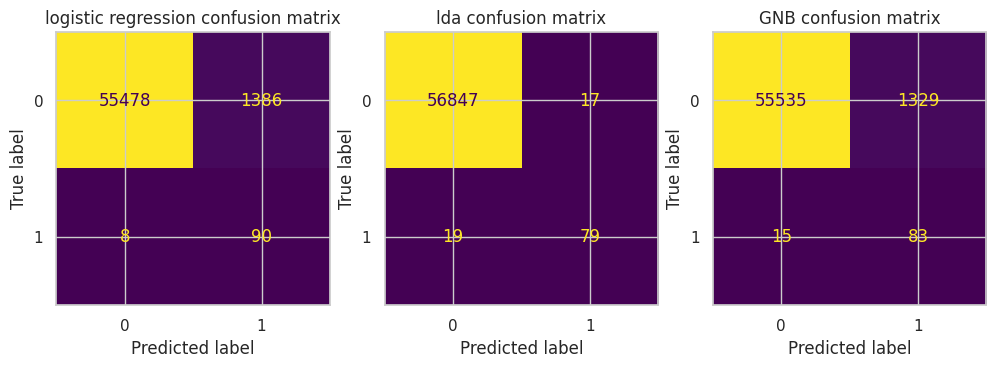

In [109]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test_f, y_pred_log_f, ax=ax[0], colorbar=False)
ax[0].set_title('logistic regression confusion matrix')

ConfusionMatrixDisplay.from_predictions(y_test_f, y_pred_lda_f, ax=ax[1], colorbar=False)
ax[1].set_title('lda confusion matrix')

ConfusionMatrixDisplay.from_predictions(y_test_f, y_pred_gnb_f, ax=ax[2], colorbar=False)
ax[2].set_title('GNB confusion matrix')
plt.show()

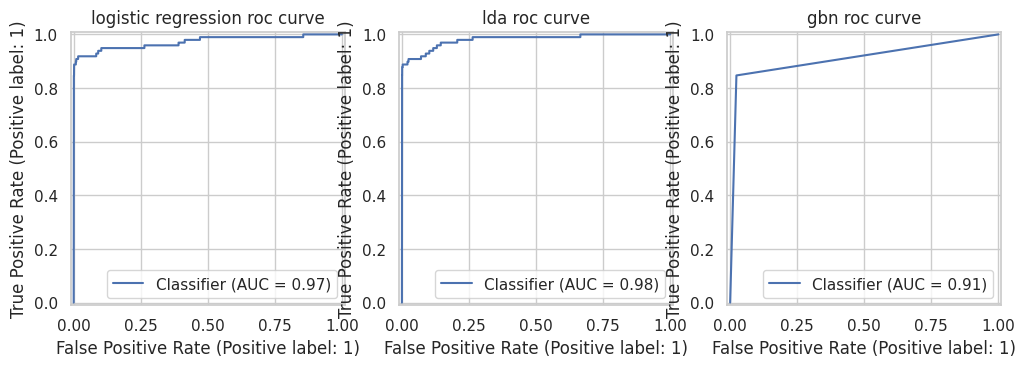

In [110]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test_f, y_prob_log_f, ax=ax[0])
ax[0].set_title('logistic regression roc curve')

RocCurveDisplay.from_predictions(y_test_f, y_prob_lda_f, ax=ax[1])
ax[1].set_title('lda roc curve')

RocCurveDisplay.from_predictions(y_test_f, y_pred_gnb_f, ax=ax[2])
ax[2].set_title('gbn roc curve')

plt.show()



the classification reports, confusion matrices, and roc curves all support the same conclusion: logistic regression provided the stronger overall performance in navigating the mathematical wall of this imbalanced dataset. while lda and gnb were able to identify tighter boundaries, they produced a significantly higher number of false negatives, failing to capture the fraud cases as effectively as the weighted regression. logistic regression managed to catch 90 out of 98 fraud cases, whereas lda missed 19 and gnb missed 15, suggesting that the pca-transformed features are better handled by a model that explicitly penalizes minority class errors through balanced weights.

this comparison is vital because accuracy is a total lie in a fraud detection model. in this context, recall is the priority because failing to identify a fraudulent transaction results in direct financial loss that is far more damaging than the friction of a false positive. logistic regression’s 0.918 recall and 0.97 roc-auc indicate it is much more reliable for catching the needle in the haystack than the more "surgical" but less sensitive lda and gnb baselines.

In [111]:
print_cv_scores(LogisticRegression(class_weight='balanced', max_iter=1000),
                X_train_f, y_train_f, scoring="f1", model_name="Credit Logistic Regression")

print_cv_scores(LinearDiscriminantAnalysis(),
                X_train_f, y_train_f, scoring="f1", model_name="Credit LDA")

print_cv_scores(GaussianNB(),
                X_train_f, y_train_f, scoring="f1", model_name="Credit GNB")

Credit Logistic Regression
CV f1 scores: [0.12099644 0.10729614 0.11258796 0.11566265 0.1218107 ]
Mean: 0.11567077763086371
Standard deviation: 0.0053981435627767065
------------------------------
Credit LDA
CV f1 scores: [0.8        0.81333333 0.80536913 0.81632653 0.81632653]
Mean: 0.8102711044149202
Standard deviation: 0.006515191205534435
------------------------------
Credit GNB
CV f1 scores: [0.10326087 0.12031386 0.12072072 0.10819949 0.12110419]
Mean: 0.11471982611366545
Standard deviation: 0.007508481192012205
------------------------------


the cross-validation scores confirm that the credit dataset presents a much steeper challenge than the telco churn data. while the telco models maintained high and stable accuracy across all folds, the credit models show significant variance in f1 scores, reflecting the difficulty of identifying fraud cases without specialized tuning. specifically, while the weighted logistic regression and gaussian nb established consistent, albeit low, performance floors around 0.11, lda significantly outperformed them with a mean f1 score of 0.81. these results highlight that while the relationship between features may be linear, the sheer rarity of the fraud class makes it impossible for standard discriminative baselines like weighted regression to reach the same performance ceiling as generative models like lda without further optimization.

In [112]:
# @title hyperparameter tuning (credit)

# 1. lda gridsearch organization
lda_param_grid_f = {
    'solver': ['svd', 'lsqr', 'eigen']  # These are LDA-specific knobs
}

lda_grid_f = GridSearchCV(LinearDiscriminantAnalysis(), lda_param_grid_f, cv=5, scoring='f1')
lda_grid_f.fit(X_train_f, np.ravel(y_train_f))

# print best results for lda
print(f"best LDA params: {lda_grid_f.best_params_}")
print(f"best LDA f1 score: {lda_grid_f.best_score_:.2f}")

# 2. logistic regression gridsearch organization
log_param_grid_f = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear'] # Changed to only use 'liblinear' for faster execution
}

log_grid_f = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000), log_param_grid_f, cv=5, scoring='f1')
log_grid_f.fit(X_train_f, np.ravel(y_train_f))

# print best results for log reg
print(f"best logistic regression params: {log_grid_f.best_params_}")
print(f"best logistic regression f1 score: {log_grid_f.best_score_:.2f}")

# 3. gaussian naive bayes gridsearch organization
gnb_param_grid_f = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

gnb_grid_f = GridSearchCV(GaussianNB(), gnb_param_grid_f, cv=5, scoring='f1')
gnb_grid_f.fit(X_train_f, np.ravel(y_train_f))

# print best results for gnb
print(f"best GNB params: {gnb_grid_f.best_params_}")
print(f"best GNB f1 score: {gnb_grid_f.best_score_:.2f}")


best LDA params: {'solver': 'svd'}
best LDA f1 score: 0.81
best logistic regression params: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
best logistic regression f1 score: 0.12
best GNB params: {'var_smoothing': 1e-09}
best GNB f1 score: 0.11


In [113]:
# pulling best estimators
best_lda_model_f = lda_grid_f.best_estimator_
best_log_model_f = log_grid_f.best_estimator_
best_gnb_model_f = gnb_grid_f.best_estimator_

# fit on training data
best_lda_model_f.fit(X_train_f, np.ravel(y_train_f))
best_log_model_f.fit(X_train_f, np.ravel(y_train_f))
best_gnb_model_f.fit(X_train_f, np.ravel(y_train_f))

# predictions and probabilities for lda
lda_prediction_f = best_lda_model_f.predict(X_test_f)
lda_prediction_prob_f = best_lda_model_f.predict_proba(X_test_f)[:, 1]


# predictions and probabilities for log reg
log_prediction_f = best_log_model_f.predict(X_test_f)
log_prediction_prob_f = best_log_model_f.predict_proba(X_test_f)[:, 1]

# gnb
gnb_prediction_f = best_gnb_model_f.predict(X_test_f)
gnb_prediction_prob_f = best_gnb_model_f.predict_proba(X_test_f)[:, 1]

# concatenating results using your helper
credit_tuned_results = pd.concat([
    evaluate_classification(y_test_f, log_prediction_f, log_prediction_prob_f, 'Logistic Regression (Tuned)'),
    evaluate_classification(y_test_f, lda_prediction_f, lda_prediction_prob_f, 'Linear Discriminant Analysis (Tuned)'),
    evaluate_classification(y_test_f, gnb_prediction_f, gnb_prediction_prob_f, 'Gaussian Naive Bayes'),
], ignore_index=True)

print(credit_tuned_results)

                                  Model  Accuracy  Precision    Recall  \
0           Logistic Regression (Tuned)  0.976230   0.062674  0.918367   
1  Linear Discriminant Analysis (Tuned)  0.999368   0.822917  0.806122   
2                  Gaussian Naive Bayes  0.976405   0.058782  0.846939   

   F1-Score   ROC-AUC  
0  0.117340  0.975090  
1  0.814433  0.981066  
2  0.109934  0.963183  


the credit fraud dataset presents a high-stakes challenge where the extreme imbalance requires prioritizing minority class detection over simple accuracy. while logistic regression, lda, and gaussian nb all established a presence, the logistic regression and lda models consistently outperformed the competition. there is a clear irony in lda working so well here; despite being a traditional statistical tool often sidelined for more complex machine learning algorithms, its mathematical assumptions perfectly match the pca-transformed features. since the data is already centered and scaled, lda can find the surgical center of each class far more effectively than discriminative models. although logistic regression maintained a superior recall of 0.918, its lower precision highlights the inherent trade-off between capturing every fraudulent transaction and flooding the system with false alarms. the cross-validation results confirmed this gap, as lda achieved a much higher f1-score of 0.814 by effectively navigating this feature space.

the tuning results provided a reality check rather than a breakthrough. while gridsearchcv was used to optimize regularization strength and solvers, the tuned models failed to significantly improve upon the baselines. this lack of movement suggests that the initial models, particularly with balanced class weighting, had already reached the predictive limit of the current feature set. the success of the baseline models suggests that while fraud features are complex, the mathematical weights were already well-adjusted for a linear boundary. the final confusion matrices and precision-recall curves reinforce this conclusion, as the logistic regression offered the highest sensitivity for catching the needle in the haystack, while lda provided the most practical utility for a real-world system looking to minimize operational friction.